# Live Coding BAB 8 KAL - Regresi

Nama: Hassan Nashrallah

NIM: 245150200111025

Kita akan menganalisis dataset "Salary_dataset.csv" yang berisi informasi tentang gaji karyawan berdasarkan pengalaman kerja mereka. Dataset ini memiliki dua kolom utama:

YearsExperience: Lama pengalaman kerja karyawan (dalam tahun)
Salary: Gaji tahunan karyawan (dalam satuan mata uang tertentu)

- Implementasikan model Regresi Linear sederhana untuk memprediksi gaji - berdasarkan pengalaman
- Implementasikan model Regresi Polinomial untuk memprediksi gaji dengan lebih akurat
- Evaluasi dan bandingkan kedua model menggunakan metrik MSE (Mean Squared Error)
- Visualisasikan hasil prediksi kedua model




Epoch 0, w0: 1520.08, w1: 9700.09, MSE: 6503107277.73
Epoch 10, w0: 2898.90, w1: 12671.40, MSE: 133244549.20
Epoch 20, w0: 3784.52, w1: 12541.42, MSE: 125181644.13
Epoch 30, w0: 4634.40, w1: 12416.68, MSE: 117756261.31
Epoch 40, w0: 5449.99, w1: 12296.98, MSE: 110917992.79
Epoch 50, w0: 6232.68, w1: 12182.11, MSE: 104620416.28
Epoch 60, w0: 6983.78, w1: 12071.87, MSE: 98820780.06
Epoch 70, w0: 7704.58, w1: 11966.08, MSE: 93479712.69
Epoch 80, w0: 8396.30, w1: 11864.56, MSE: 88560955.81
Epoch 90, w0: 9060.10, w1: 11767.14, MSE: 84031117.93
Final MSE: 79859447.79


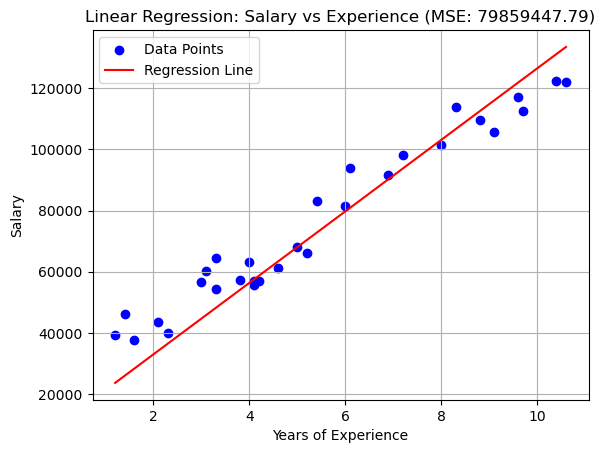

In [ ]:
# Implementasi model regresi linier sederhana 
# untuk memprediksi gaji berdasarkan pengalaman kerja

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv(r'C:\Users\hassa\OneDrive\Dokumen\praktikumz\kal-praktikum\data\Salary_dataset.csv')
X = df['YearsExperience'].values
y = df['Salary'].values

# 2. Pembuatan fitur regresi linier
w0 = 0
w1 = 0
alpha = 0.01
epochs = 100
m = len(X)

# 3. Training menggunakan gradient descent
for epoch in range(epochs):
    y_pred = w0 + w1 * X
    error = y_pred - y 
    grad0 = (2/m) * np.sum(error)
    grad1 = (2/m) * np.sum(error * X)
    w0 -= alpha * grad0
    w1 -= alpha * grad1

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, w0: {w0:.2f}, w1: {w1:.2f}, MSE: {np.mean(error ** 2):.2f}')

# 4. Final Mean Squared Error (MSE)
y_pred_final = w0 + w1 * X
mse = np.mean((y_pred_final - y) ** 2)
print(f"Final MSE: {mse:.2f}")

# 5. Visualisasi grafik scatter plot dan garis regresi
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, w0 + w1 * X, color='red', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title(f'Linear Regression: Salary vs Experience (MSE: {mse:.2f})')
plt.grid()
plt.legend()
plt.show()

Epoch 0: MSE = 1.000000
Epoch 1000: MSE = 0.037133
Epoch 2000: MSE = 0.036406
Epoch 3000: MSE = 0.036403
Epoch 4000: MSE = 0.036403
Epoch 5000: MSE = 0.036403
Epoch 6000: MSE = 0.036403
Epoch 7000: MSE = 0.036403
Epoch 8000: MSE = 0.036403
Epoch 9000: MSE = 0.036403

Final MSE (in original scale): 26446769.61


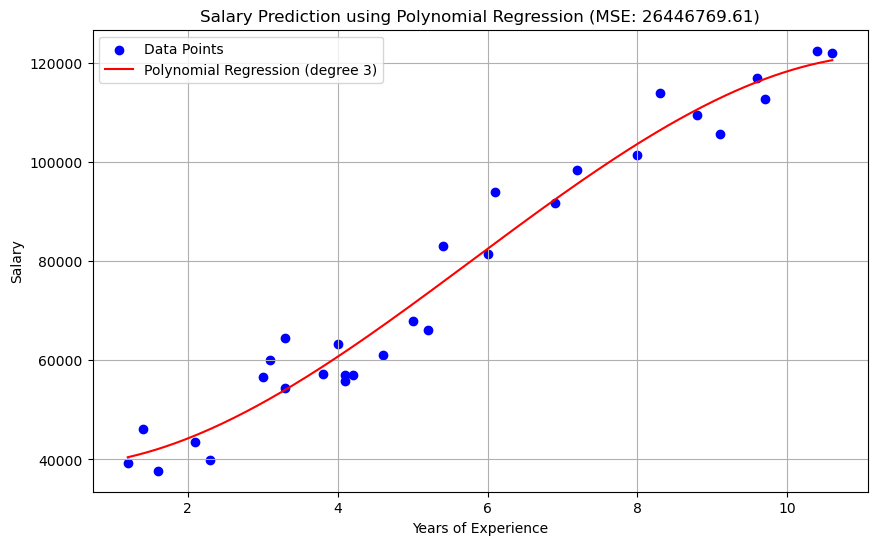

In [12]:
# Implementasi model regresi polinomial 
# untuk memprediksi gaji dengan lebih akurat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load intercept dan slope dari dataset
X = df[['YearsExperience']].values
y = df['Salary'].values
m = len(y)

# 2. Normalisasi X dengan StandardScaler
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

# 3. Pembuatan fitur polinomial derajat 3
X_poly = np.hstack((np.ones((m, 1)), X_scaled, X_scaled**2, X_scaled**3))
w_poly = np.zeros(X_poly.shape[1])

# 4. Normalisasi y untuk training
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# 4. Training menggunakan gradient descent
epochs = 10000
alpha = 0.01

for epoch in range(epochs):
    y_pred = X_poly @ w_poly
    error = y_pred - y_scaled
    gradients = (2/m) * (X_poly.T @ error)
    w_poly -= alpha * gradients

    if epoch % 1000 == 0:
        mse = np.mean(error ** 2)
        print(f'Epoch {epoch}: MSE = {mse:.6f}')

# 5. Final MSE dalam skala asli
y_pred_scaled = X_poly @ w_poly
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
mse_poly = np.mean((y_pred_original - y) ** 2)
print(f"\nFinal MSE (in original scale): {mse_poly:.2f}")

# 6. Visualisasi grafik scatter plot dan kurva regresi polinomial
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot_scaled = scaler_x.transform(X_plot)
X_plot_poly = np.hstack((np.ones((300, 1)), X_plot_scaled, X_plot_scaled**2, X_plot_scaled**3))
y_plot_scaled = X_plot_poly @ w_poly
y_plot = scaler_y.inverse_transform(y_plot_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_plot, y_plot, color='red', label='Polynomial Regression (degree 3)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title(f'Salary Prediction using Polynomial Regression (MSE: {mse_poly:.2f})')
plt.grid()
plt.legend()
plt.show()

## Kesimpulan

Buat kesimpulan berdasarkan hasil model regresi yang telah dibuat! Apa perbedaan dari kedua model regresi, Linear dan Polinomial, dalam memprediksikan data? Bagaimana perbedaan hasil yang diberikan dari kedua model tersebut?

Kesimpulan: 

Berdasarkan hasil percobaan, kedua model regresi sama-sama mampu memprediksi hubungan antara pengalaman kerja dan gaji, namun menghasilkan performa yang berbeda. Pada regresi linear, model membentuk hubungan garis lurus antara pengalaman kerja dan gaji. Sementara itu, regresi polinomial derajat 3 mampu membentuk kurva yang lebih fleksibel sehingga dapat mengikuti pola data yang tidak sepenuhnya linear. 

Model Linear menghasilkan MSE yang jauh lebih besar (sekitar 79,8 juta) karena garis lurus tidak mampu menangkap pola pertumbuhan gaji yang sebenarnya tidak sepenuhnya linear. Hal ini terlihat dari grafik di mana garis melewati banyak titik data dengan jarak yang cukup jauh, terutama di ujung bawah dan atas. Sementara itu, model Polinomial menghasilkan MSE yang lebih kecil (sekitar 26,4 juta) dan kurvanya mengikuti pola data dengan lebih baik. Dapat dilihat dari grafik, garis polinomial membentuk S-curve yang menyesuaikan dengan persebaran titik data. Sehingga, model polinomial menangkap pertumbuhan gaji yang lebih cepat di awal karir dan melambat di tahun-tahun akhir. Dengan demikian, model regresi polinomial memberikan performa prediksi gaji yang lebih baik dibandingkan regresi linear pada dataset tersebut.